# 02-03 - Three Maps, One Dataset

On Monday one variable became three maps with three headlines, and all three were correct. That variable was the number of buildings in each 250 metre cell of a grid laid over Princeton, and the grid is in our data folder, cell for cell the one the lecture's figures were drawn from.

Here we classify it three ways and count who lands where, and colour it two ways and see which one invents a midpoint the data does not have. Then we measure the same cells twice, by count and by built share, and find that the two top threes have not one cell in common. Every number the lecture showed comes out of your own kernel.

Save your own copy first, with `-mywork` in the name.

In [1]:
import json
import warnings

import geopandas as gpd
import mapclassify
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

warnings.filterwarnings("ignore", message="Numba not installed")   # the one warning this course silences, explained below
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

One warning is silenced in the cell above, on purpose, and it is the only one this course ever silences. `mapclassify` says once per session that it is running without an accelerator called Numba, which changes how fast it runs and nothing about what it computes. Every other warning you meet this semester, read.

## The lecture's grid

The grid was made by laying 250 metre squares over the State's boundary of Princeton, keeping every square that touches the town, and counting the OpenStreetMap buildings whose centre falls in each. The buildings are the P01 extract, mapped by volunteers and licensed ODbL, which the grid inherits and credits in its own metadata. Let us read it and ask the usual first questions:

In [2]:
grid = gpd.read_file("data/princeton_grid_250m.gpkg", layer="grid")

print(grid.crs)
print(f"{grid.geometry.area.iloc[0]:,.0f} square metres per cell, i.e. {grid.geometry.area.iloc[0] ** 0.5:.0f} metres on a side")
print(f"{len(grid)} cells, {int(grid['n'].sum()):,} buildings counted")
grid.head(3)

EPSG:26918
62,500 square metres per cell, i.e. 250 metres on a side
839 cells, 7,893 buildings counted


,n,built_m2,frac,geometry
0,0,0.0,0.0,"POLYGON ((523837.511 4468644.522, 523837.511 4..."
1,0,0.0,0.0,"POLYGON ((523837.511 4468894.522, 523837.511 4..."
2,0,0.0,0.0,"POLYGON ((523837.511 4469144.522, 523837.511 4..."


Eight hundred and thirty nine cells in metres, and every one of the 7,893 buildings from P01 is counted in exactly one of them. Three columns besides the geometry: `n`, the count of buildings; `built_m2`, the square metres of building footprint inside the cell; and `frac`, that footprint as a share of the cell's area. Every cell is 62,500 square metres, i.e. 250 metres on a side, which is both the units check and the denominator behind `frac`. The first column is the variable of the lecture's classification slides; the last two are for the end of this notebook.

## One variable, three sets of breaks

A **choropleth** is a map that colours each zone by the value of one variable, and a **classification scheme** is the rule that decides where the boundaries between the colour classes go. The lecture named three. Equal interval cuts the range into classes of equal width. Quantiles cuts it so that each class holds the same number of zones. Natural breaks puts the cuts where the data has gaps, so that each class varies least inside; the `mapclassify` library calls it FisherJenks, after the two people who worked out how to find those gaps. `k=5` asks each scheme for five classes, and the `counts` attribute tells us how many cells each class received:

In [3]:
NAMES = {"EqualInterval": "equal interval", "Quantiles": "quantiles", "FisherJenks": "natural breaks"}

for scheme in NAMES:
    classes = mapclassify.classify(grid["n"], scheme, k=5)
    print(f"{NAMES[scheme]:15} {classes.counts.tolist()}   largest class {classes.counts.max() / len(grid):.0%}")

print(f"cells with no buildings at all   {int((grid['n'] == 0).sum())}")
print(f"busiest cell {grid['n'].max()} buildings, median of the cells that hold any {grid.loc[grid['n'] > 0, 'n'].median():.0f}")

equal interval  [725, 79, 25, 8, 2]   largest class 86%
quantiles       [211, 157, 149, 168, 154]   largest class 25%


natural breaks  [418, 229, 117, 51, 24]   largest class 50%
cells with no buildings at all   211
busiest cell 101 buildings, median of the cells that hold any 8


These are the three rows of the lecture's table, and they came from the same 839 numbers. Equal interval put 725 of them in its first class, i.e. 86 percent of the town in one colour, with two cells alone in the top class. Quantiles aimed at a fifth of the cells in each class, i.e. about 168, and delivered 211, 157, 149, 168, 154. Note that a quantile break cannot split a tie, and 211 cells hold no buildings at all, so the first class is exactly the cells with zero and the promise of equal counts breaks on the ties. Natural breaks tapered them 418, 229, 117, 51, 24. Same data, three honest answers to "which cells are alike".

The pipeline that made the grid recorded the same three rows, so we can check that nothing has drifted:

In [4]:
reference = json.load(open("data/ground_truth.json"))["p02"]
for scheme in NAMES:
    counts = mapclassify.classify(grid["n"], scheme, k=5).counts.tolist()
    print(f"{NAMES[scheme]:15} computed {counts}  recorded {reference['grid']['occupancy'][scheme]}")

equal interval  computed [725, 79, 25, 8, 2]  recorded [725, 79, 25, 8, 2]
quantiles       computed [211, 157, 149, 168, 154]  recorded [211, 157, 149, 168, 154]


natural breaks  computed [418, 229, 117, 51, 24]  recorded [418, 229, 117, 51, 24]


Three rows, twice, identical, i.e. the file on disk and this kernel agree.

## Three maps

Let us draw them, side by side, with the same five sequential colours, so that the only thing that differs between the panels is the rule:

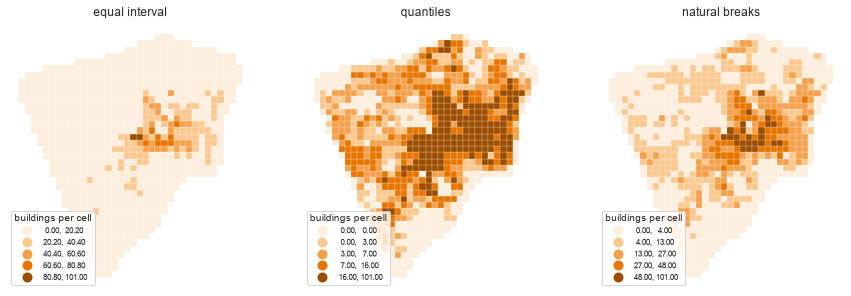

In [5]:
ORANGES = ListedColormap(["#fdeedd", "#fbc98f", "#f5a04a", "#e77500", "#9c4d00"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, scheme in zip(axes, NAMES):
    grid.plot(column="n", scheme=scheme, k=5, cmap=ORANGES, edgecolor="white", linewidth=0.2, ax=ax,
              legend=True, legend_kwds={"loc": "lower left", "fontsize": 8, "title": "buildings per cell"})
    ax.set_title(NAMES[scheme])
    ax.set_axis_off()

Three maps and three headlines. The first says Princeton is almost empty with two dense specks. The second says the town is built almost everywhere, with a solid core in the centre east and busier cells scattered through the rest. The third says most of it is quiet and the core is compact. Every one is a true statement about the same 839 counts, and a reader who sees only one of them has no way of knowing that the other two exist.

Note the legends. Each states its class boundaries, which is the one thing a choropleth must never omit, and the boundaries alone tell a careful reader which rule was used. The lecture's advice was blunt, that the legend of a classed map is the first thing to scrutinise.

## The histogram first

Why did equal interval put 725 cells in one class? Because the values are skewed. Most cells hold a handful of buildings, the busiest single cell holds about a hundred, so a rule that cuts the range into five equal widths spends its other four classes on the 79, 25, 8 and 2 cells above its first break. The instrument for seeing this before you classify anything is a histogram, with each scheme's breaks drawn on it. The `bins` attribute holds the upper edge of each class, and we drop the last one, i.e. the maximum, because it is the right edge of the data and not a cut:

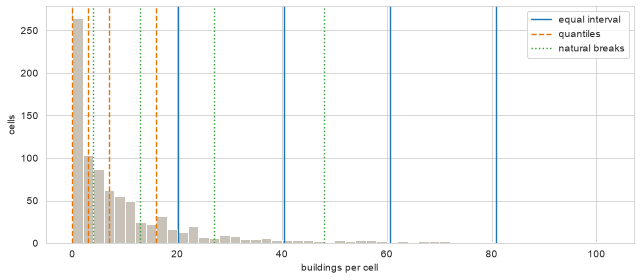

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(grid["n"], bins=np.arange(0, 104, 2), color="#c8c2b8")  # two counts per bin, so no bin straddles an integer
for scheme, colour, style in (("EqualInterval", "#1f77b4", "-"), ("Quantiles", "#e77500", "--"), ("FisherJenks", "#2ca02c", ":")):
    for i, b in enumerate(mapclassify.classify(grid["n"], scheme, k=5).bins[:-1]):
        # label the first line of each scheme only, so the legend has three entries and not twelve
        ax.axvline(b, color=colour, linestyle=style, linewidth=1.4, label=NAMES[scheme] if i == 0 else None)
ax.set_xlabel("buildings per cell")
ax.set_ylabel("cells")
ax.legend()
fig.tight_layout()

The blue solid lines, equal interval, sit far to the right where almost no cells are. The orange dashed lines, quantiles, crowd the left where the cells are. The green dotted lines, natural breaks, do both, i.e. two of them cut close together where the cells are many and two sit far apart out in the tail, which is what minimising the variation inside each class buys you. Look at the histogram before you touch a classifier, and most of the argument about which scheme to use answers itself.

One more thing worth knowing. Two cartographers, Brewer and Pickle, put seven classification schemes in front of 56 readers in 2002 and measured how accurately the readers took numbers off the maps. Quantiles did best and natural breaks fell well behind, which matters because natural breaks is what ArcGIS preselects for a graduated map. And yet the lecture's caveat stands. No scheme is objective, a classification is a choice, and a threshold the audience already believes in beats all three when one exists. Note that such a threshold is usually written down somewhere, for example the floor area limit a zone allows, or a flood level, or the assessment ratio the county audits against, and when it exists the break belongs there and the map's only job is above or below.

## The wrong colours

The lecture separated two kinds of colour ramp. A **sequential** ramp runs one hue from light to dark and says "more" or "less". A **diverging** ramp runs two hues that meet at a neutral middle and says "above" or "below" some meaningful midpoint. Here is the building count on a diverging ramp, which is a mistake, drawn deliberately:

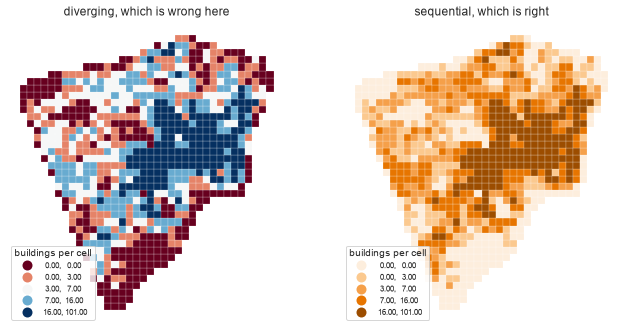

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
grid.plot(column="n", scheme="Quantiles", k=5, cmap="RdBu", edgecolor="white", linewidth=0.2, ax=axes[0], legend=True,
          legend_kwds={"loc": "lower left", "fontsize": 8, "title": "buildings per cell"})
axes[0].set_title("diverging, which is wrong here")
grid.plot(column="n", scheme="Quantiles", k=5, cmap=ORANGES, edgecolor="white", linewidth=0.2, ax=axes[1], legend=True,
          legend_kwds={"loc": "lower left", "fontsize": 8, "title": "buildings per cell"})
axes[1].set_title("sequential, which is right")
for ax in axes:
    ax.set_axis_off()

On the left the middle quantile is painted the palest colour of all, as if cells with a middling number of buildings were the natural zero and the red and blue cells were departures from it in opposite directions. Nothing in the data says that. There is no midpoint of building counts that means anything, so the map has invented one. On the right the same classes run from pale to dark and say only what is true, i.e. more buildings, darker cell.

Note that this is not a matter of taste. A rainbow ramp or a diverging ramp on a plain quantity plants a boundary in the reader's eye that the data does not contain, and readers act on what they see. The rule is short. Sequential for quantities, diverging for departures from a meaningful middle.

## Count against share

The lecture ended its chapter with a trap that has nothing to do with classifiers or colours. The grid carries a second measurement of the same cells, the share of each cell's ground that is covered by building footprint. Let us rank the cells both ways and look at the leaders, and then ask how often the two quantile maps drawn below put a cell in the same class. The `yb` attribute is the class each cell landed in, numbered 0 to 4, so the bottom two classes are 0 and 1 and the top one is 4:

In [8]:
by_count = grid["n"].nlargest(3).index
by_share = grid["frac"].nlargest(3).index

print(f"top three by count, square metres of footprint per building    {grid.loc[by_count, 'built_m2'].sum() / grid.loc[by_count, 'n'].sum():.0f}")
print(f"top three by share, square metres of footprint per building    {grid.loc[by_share, 'built_m2'].sum() / grid.loc[by_share, 'n'].sum():.0f}")
print(f"cells the two top threes have in common                        {len(set(by_count) & set(by_share))}")

count_class = mapclassify.classify(grid["n"], "Quantiles", k=5).yb
share_class = mapclassify.classify(grid["frac"], "Quantiles", k=5).yb
few_but_big = grid[(share_class == 4) & (count_class <= 1)]
print(f"cells in the same quantile class by count and by share         {int((count_class == share_class).sum())} of {len(grid)}")
print(f"cells in the top share class and the bottom two count classes  {len(few_but_big)}, holding {few_but_big['n'].min()} to {few_but_big['n'].max()} buildings each")

top three by count, square metres of footprint per building    140
top three by share, square metres of footprint per building    1066
cells the two top threes have in common                        0
cells in the same quantile class by count and by share         595 of 839
cells in the top share class and the bottom two count classes  9, holding 1 to 3 buildings each


The three cells with the most buildings hold buildings of about 140 square metres each, i.e. houses, and they are the dense residential streets. The three cells with the largest built share hold buildings of about a thousand square metres each, i.e. the campus, where a few large structures cover the ground. The two lists share no cell. "Where is Princeton most built up" has two answers, and which one you get depends on a choice made before the first line of code, i.e. whether you counted things or measured them. The last two lines are for reading against the maps.

Here they are side by side:

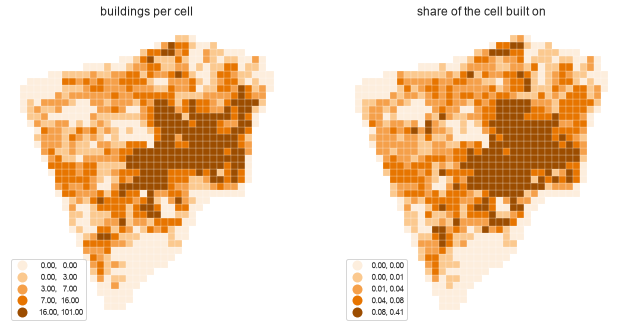

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, column, title in zip(axes, ("n", "frac"), ("buildings per cell", "share of the cell built on")):
    grid.plot(column=column, scheme="Quantiles", k=5, cmap=ORANGES, edgecolor="white", linewidth=0.2, ax=ax, legend=True,
              legend_kwds={"loc": "lower left", "fontsize": 8})
    ax.set_title(title)
    ax.set_axis_off()

The left map finds the houses. The right map finds the ground that is covered. The two agree on most cells, i.e. 595 of the 839 fall in the same class on both, and what differs is why a cell is dark. On the left it is dark because it holds many buildings, on the right because a few buildings cover a lot of its ground, and the nine cells that sit in the top class of built share and the bottom two classes of count hold one to three very large buildings each and nothing else. Neither map is wrong, and a title that says "most built up" is wrong on both of them, because it does not say which. A title is a sentence, and the sentence has to name the measure, i.e. the most houses per cell, or the most ground under roof.

This is the lecture's denominator lesson in miniature, and 02-04 turns it into the poster's central decision.

## Check your understanding

1. Equal interval put 725 of 839 cells in its first class. Say in one sentence, from the histogram, why, and name the scheme whose classes are guaranteed to hold about the same number of cells.
2. Brewer and Pickle found that quantiles read most accurately, and the lecture said that does not make quantiles correct. We named thresholds an audience already believes in. Pick one and say what its map would show that quantiles would hide.
3. The diverging ramp put a near-white class in the middle of the building counts. What did that neutral middle claim, and was the claim true?
4. The three cells with the most buildings and the three with the largest built share have no cell in common. Which map answers "where are the houses" and which "where is the ground covered", and what must each title say?

## Where we are

You can classify one variable three ways and read the class occupancy, you know why a skewed variable defeats equal interval and how a histogram shows it in advance, you can tell a sequential ramp from a diverging one and say when each is honest, and you have seen that a count and a share of the same cells rank them in different orders. Every number the lecture showed is now one you have computed.

The habit worth keeping: look at the histogram first, and put the scheme and the class boundaries in the legend, so a reader can see what you chose.

In 02-04 we leave the grid for the municipality's own tax blocks, choose a denominator out loud, and export the map the December poster will need.

## Further resources

Nothing in this course requires anything below.

The `mapclassify` documentation lists every scheme it implements, with the algorithm behind each: https://pysal.org/mapclassify/api.html

ColorBrewer, by Cynthia Brewer, is the standard set of sequential, diverging and qualitative colour schemes, with a check for colour vision deficiency, and the schemes matplotlib ships under the same names come from it: https://colorbrewer2.org/

The reader study is Brewer, C. A. and Pickle, L. (2002), Evaluation of methods for classifying epidemiological data on choropleth maps in series, Annals of the Association of American Geographers, 92(4), 662 to 681.

The grid is derived from the OpenStreetMap buildings extract of P01, snapshot as recorded in `data/README.org`, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright